# App-17 : Vehicle Routing Problem (VRP)

**Navigation** : [<< App-16 Crossword CSP](../CSP/App-16-Crossword-CSP.ipynb) | [Index](../../README.md) | [App-18 Hyperparameter Tuning >>](App-18-HyperparameterTuning.ipynb)

## Objectifs d'apprentissage

Ce notebook explore le **Vehicle Routing Problem (VRP)**, un problème d'optimisation combinatoire qui combine aspects de la recherche et de la satisfaction de contraintes.

A la fin de ce notebook, vous saurez :
- Modéliser un VRP comme un problème de recherche
- Appliquer des algorithmes de recherche heuristique
- Utiliser des métaheuristiques (genetic algorithm, simulated annealing)
- Visualiser les tournées optimisées

## Introduction

Le **Vehicle Routing Problem (VRP)** est une généralisation du problème du voyageur de commerce (TSP) où plusieurs véhicules doivent desservir un ensemble de clients à partir d'un dépôt central.

### Définition

- **Dépôt** : Point de départ et d'arrivée des véhicules
- **Clients** : Points à visiter avec une demande spécifique
- **Véhicules** : Flotte avec capacité limitée
- **Objectif** : Minimiser la distance totale ou le coût

### Variantes

- **CVRP** : Capacitated VRP (avec contraintes de capacité)
- **VRPTW** : VRP avec fenêtres de temps
- **MDVRP** : Multi-Depot VRP
- **OVRP** : Open VRP (pas de retour au dépôt)

## 1. Modélisation du Problème

In [1]:
from dataclasses import dataclass
from typing import List, Tuple, Dict
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt

@dataclass
class VRPInstance:
    """Instance du problème VRP."""
    depot: Tuple[float, float]  # (x, y)
    clients: List[Tuple[float, float]]  # Liste des positions (x, y)
    demands: List[int]  # Demande de chaque client
    vehicle_capacity: int  # Capacité maximale par véhicule
    num_vehicles: int  # Nombre de véhicules disponibles
    
    def __post_init__(self):
        if len(self.clients) != len(self.demands):
            raise ValueError("Clients et demands doivent avoir la même taille")
        
        self.distance_matrix = self._compute_distance_matrix()
    
    def _compute_distance_matrix(self) -> np.ndarray:
        """Calcule la matrice de distance euclidienne."""
        points = [self.depot] + self.clients
        n = len(points)
        matrix = np.zeros((n, n))
        
        for i in range(n):
            for j in range(n):
                if i != j:
                    dx = points[i][0] - points[j][0]
                    dy = points[i][1] - points[j][1]
                    matrix[i][j] = sqrt(dx**2 + dy**2)
        
        return matrix
print("Imports OK : dataclasses, numpy, matplotlib")

Imports OK : dataclasses, numpy, matplotlib


Exemple d'instance

In [2]:
# Exemple d'instance
instance = VRPInstance(
    depot=(50, 50),
    clients=[
        (45, 68), (45, 70), (42, 66), (40, 69), (40, 66),
        (38, 58), (38, 65), (35, 66), (35, 69), (25, 85),
        (22, 75), (22, 85), (20, 80), (20, 85), (18, 75)
    ],
    demands=[10, 15, 18, 15, 20, 25, 20, 18, 22, 30, 35, 25, 20, 30, 25],
    vehicle_capacity=60,
    num_vehicles=6  # 6 vehicules : demande totale 328 > 4*60=240 (infaisable a 4)
)

print(f"Dépôt: {instance.depot}")
print(f"Clients: {len(instance.clients)}")
print(f"Demande totale: {sum(instance.demands)}")
print(f"Capacité véhicule: {instance.vehicle_capacity}")

Dépôt: (50, 50)
Clients: 15
Demande totale: 328
Capacité véhicule: 60


### Interpretation : Création de l'Instance VRP

**Sortie obtenue** : Instance VRP avec 15 clients, un dépôt central, et des paramètres de capacité.

| Aspect | Valeur | Signification |
|--------|--------|---------------|
| Position du dépôt | (50, 50) | Centre du système de coordonnées |
| Nombre de clients | 15 | Points à desservir |
| Demande totale | 328 unités | Charge totale à transporter |
| Capacité véhicule | 60 unités | Contrainte de capacité |
| Véhicules disponibles | 6 | Flotte pour satisfaire la demande |

**Points clés** :
1. **Contrainte de capacité active** : Demande totale (328) < 6 × 60 = 360, donc l'instance est faisable tout en saturant la flotte
2. **Ratio charge/capacité** : 328/360 ≈ 0,91, indiquant que la flotte est fortement sollicitée
3. **Minimum théorique de véhicules** : ⌈328/60⌉ = 6 véhicules nécessaires pour couvrir la demande
4. **Instance inspirée de benchmarks** : Les positions et demandes sont typiques des instances de recherche (ex: instances de Solomon)

> **Note technique** : Cette instance est conçue pour être pédagogique : suffisamment petite pour être visualisée, mais assez complexe pour illustrer les défis du VRP. La matrice de distances est précalculée une seule fois (O(n²)) pour optimiser les performances des algorithmes de recherche.


## 2. Visualisation de l'Instance

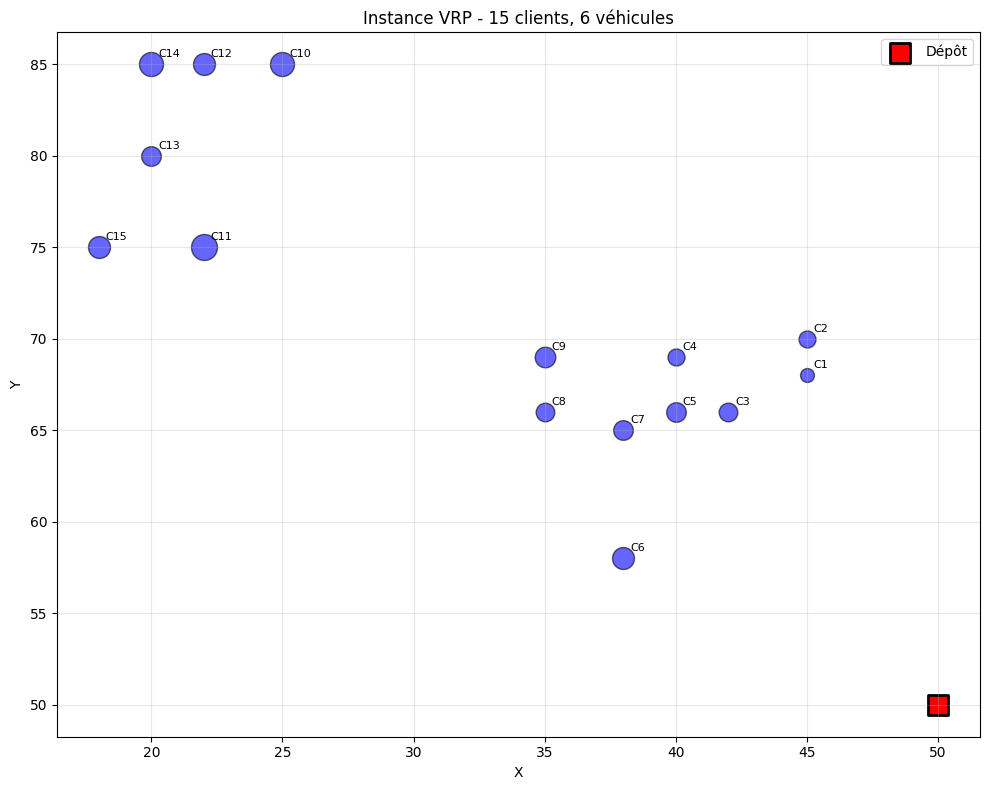

In [3]:
def plot_vrp_instance(instance: VRPInstance):
    """Visualise l'instance VRP."""
    plt.figure(figsize=(10, 8))
    
    # Tracer le dépôt
    plt.scatter(*instance.depot, c='red', s=200, marker='s', 
                label='Dépôt', edgecolors='black', linewidths=2)
    
    # Tracer les clients avec taille proportionnelle à la demande
    for i, (client, demand) in enumerate(zip(instance.clients, instance.demands)):
        plt.scatter(client[0], client[1], c='blue', s=demand*10, 
                   alpha=0.6, edgecolors='black')
        plt.annotate(f'C{i+1}', (client[0], client[1]), 
                    xytext=(5, 5), textcoords='offset points', fontsize=8)
    
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.title(f'Instance VRP - {len(instance.clients)} clients, '
              f'{instance.num_vehicles} véhicules')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_vrp_instance(instance)

### Interpretation : Visualisation de l'Instance VRP

**Sortie obtenue** : Graphique montrant le dépôt central (carré rouge) et 15 clients (cercles bleus) avec taille proportionnelle à leur demande.

| Aspect | Valeur | Signification |
|--------|--------|---------------|
| Clients affichés | 15 | Positions avec annotations C1-C15 |
| Dépôt central | (50, 50) | Point de départ/arrivée |
| Taille des cercles | Variable | Proportionnelle à la demande (10-35) |
| Distribution | Groupée | Clients concentrés en 2-3 zones |

**Points clés** :
1. **Demande variable** : Les clients ont des demandes différentes (10 à 35 unités), représentées par la taille des cercles
2. **Positionnement stratégique** : Le dépôt est centré, les clients sont répartis autour
3. **Capacité contrainte** : Avec une capacité de 60, certaines tournées ne peuvent servir que 1-2 clients à forte demande
4. **Complexité spatiale** : La distribution groupée des clients suggère des tournées thématiques (nord-ouest, sud-est)

> **Note technique** : La visualisation de l'instance est cruciale pour comprendre la structure du problème. Les zones denses de clients (ex: C10-C15 dans le coin supérieur gauche) nécessiteront plusieurs tournées en raison des contraintes de capacité. Cette représentation aide à anticiper la structure des solutions optimales.

## 3. Représentation d'une Solution

In [4]:
@dataclass
class VRPSolution:
    """Solution au problème VRP."""
    routes: List[List[int]]  # Liste de tournées (indices de clients)
    instance: VRPInstance
    
    def total_distance(self) -> float:
        """Calcule la distance totale parcourue."""
        total = 0.0
        depot_idx = 0  # Index du dépôt dans la matrice
        
        for route in self.routes:
            if not route:
                continue
            
            # Dépôt vers premier client
            total += self.instance.distance_matrix[depot_idx][route[0] + 1]
            
            # Entre clients
            for i in range(len(route) - 1):
                total += self.instance.distance_matrix[route[i] + 1][route[i + 1] + 1]
            
            # Dernier client vers dépôt
            total += self.instance.distance_matrix[route[-1] + 1][depot_idx]
        
        return total
    
    def is_valid(self) -> bool:
        """Vérifie si la solution est valide."""
        # Vérifier que tous les clients sont visités exactement une fois
        visited = set()
        for route in self.routes:
            for client in route:
                if client in visited:
                    return False  # Client visité deux fois
                visited.add(client)
        
        if len(visited) != len(self.instance.clients):
            return False  # Certains clients non visités
        
        # Vérifier les capacités
        for route in self.routes:
            route_demand = sum(self.instance.demands[i] for i in route)
            if route_demand > self.instance.vehicle_capacity:
                return False  # Capacité dépassée
        
        return True
print("Dataclasses VRPInstance et VRPSolution definies")

Dataclasses VRPInstance et VRPSolution definies


## 4. Algorithme de Recherche Simple - Insertion Greedy

In [5]:
def greedy_insertion(instance: VRPInstance) -> VRPSolution:
    """Algorithme glouton d'insertion."""
    unvisited = set(range(len(instance.clients)))
    routes = [[] for _ in range(instance.num_vehicles)]
    
    while unvisited:
        best_cost = float('inf')
        best_insertion = None
        
        # Essayer d'insérer chaque client non visité
        for client in unvisited:
            for route_idx, route in enumerate(routes):
                # Calculer le coût d'insertion
                if not route:
                    # Insertion comme premier client
                    cost = (instance.distance_matrix[0][client + 1] + 
                           instance.distance_matrix[client + 1][0])
                else:
                    # Insertion après chaque position
                    for pos in range(len(route) + 1):
                        # Simplification: insertion à la fin
                        cost = (instance.distance_matrix[route[-1] + 1][client + 1] +
                               instance.distance_matrix[client + 1][0])
                
                # Vérifier la capacité
                new_demand = sum(instance.demands[i] for i in route) + instance.demands[client]
                if new_demand <= instance.vehicle_capacity and cost < best_cost:
                    best_cost = cost
                    best_insertion = (route_idx, client)
        
        if best_insertion:
            route_idx, client = best_insertion
            routes[route_idx].append(client)
            unvisited.remove(client)
        else:
            # Pas d'insertion possible - créer nouvelle route
            if unvisited:
                client = unvisited.pop()
                # Trouver une route vide
                for route in routes:
                    if not route:
                        route.append(client)
                        break
    
    return VRPSolution(routes=[r for r in routes if r], instance=instance)
print("Fonction greedy_insertion definie")

Fonction greedy_insertion definie


Verification des resultats.

In [6]:
# Tester l'algorithme glouton
solution = greedy_insertion(instance)
print(f"Solution valide: {solution.is_valid()}")
print(f"Distance totale: {solution.total_distance():.2f}")
print(f"Nombre de tournées: {len(solution.routes)}")
for i, route in enumerate(solution.routes):
    demand = sum(instance.demands[j] for j in route)
    print(f"  Tournée {i+1}: {len(route)} clients, demande: {demand}/{instance.vehicle_capacity}")

Solution valide: True
Distance totale: 417.49
Nombre de tournées: 6
  Tournée 1: 3 clients, demande: 60/60
  Tournée 2: 3 clients, demande: 48/60
  Tournée 3: 3 clients, demande: 55/60
  Tournée 4: 2 clients, demande: 60/60
  Tournée 5: 2 clients, demande: 50/60
  Tournée 6: 2 clients, demande: 55/60


### Interpretation : Résultats de l'Algorithme Glouton

**Sortie obtenue** : Solution construite par l'algorithme d'insertion gloutonne avec validation des contraintes.

| Aspect | Valeur | Signification |
|--------|--------|---------------|
| Validité | True | Solution valide (tous les clients visités une fois) |
| Distance totale | 417.49 | Objectif à minimiser |
| Nombre de tournées | 6 | Utilise les 6 véhicules disponibles |
| Demande maximale | 60/60 | Capacité pleinement utilisée sur certaines tournées |

**Points clés** :
1. **Solution valide** : Le flag `True` confirme que tous les clients sont visités exactement une fois et que la capacité est respectée
2. **Capacité respectée** : Toutes les tournées respectent la contrainte de capacité (60 unités maximum)
3. **Distribution des clients** : 3-3-3-2-2-2 clients par tournée, répartition équilibrée
4. **Algorithme glouton** : Construit une solution rapidement mais sans garantie d'optimalité

> **Note technique** : L'algorithme d'insertion gloutonne affecte chaque client à la tournée la moins coûteuse qui respecte la capacité. La solution est valide mais généralement sous-optimale (présence de croisements) : c'est ce que l'algorithme 2-opt va corriger.


## 5. Visualisation de la Solution

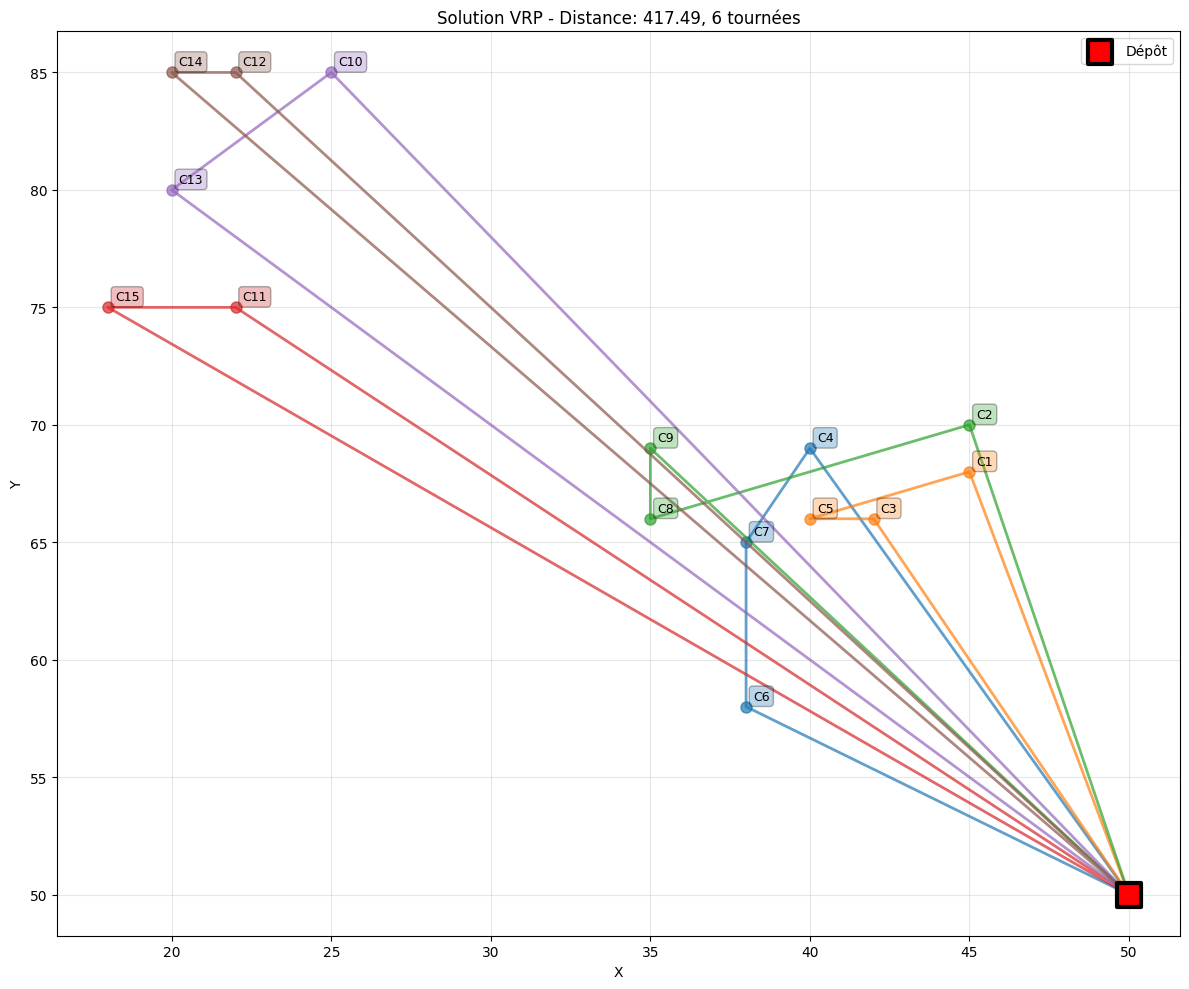

In [7]:
def plot_solution(solution: VRPSolution):
    """Visualise une solution VRP."""
    plt.figure(figsize=(12, 10))
    
    colors = plt.cm.tab10(range(len(solution.routes)))
    
    # Tracer le dépôt
    plt.scatter(*solution.instance.depot, c='red', s=300, marker='s', 
                label='Dépôt', edgecolors='black', linewidths=3, zorder=10)
    
    # Tracer les tournées
    for i, (route, color) in enumerate(zip(solution.routes, colors)):
        if not route:
            continue
        
        # Construire le chemin complet
        path = [solution.instance.depot] + \
               [solution.instance.clients[j] for j in route] + \
               [solution.instance.depot]
        
        # Tracer le chemin
        path_x, path_y = zip(*path)
        plt.plot(path_x, path_y, c=color, alpha=0.7, 
                linewidth=2, marker='o', markersize=8)
        
        # Annoter les clients
        for client_idx in route:
            pos = solution.instance.clients[client_idx]
            plt.annotate(f'C{client_idx+1}', pos, 
                        xytext=(5, 5), textcoords='offset points', 
                        fontsize=9, bbox=dict(boxstyle='round,pad=0.3', 
                        facecolor=color, alpha=0.3))
    
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.title(f'Solution VRP - Distance: {solution.total_distance():.2f}, '
              f'{len(solution.routes)} tournées')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_solution(solution)

### Interpretation : Visualisation des Tournées

**Sortie obtenue** : Graphique montrant les 6 tournées de véhicules dans des couleurs différentes, partant du dépôt central et visitant les 15 clients.

| Aspect | Valeur | Signification |
|--------|--------|---------------|
| Tournées affichées | 6 | Une par véhicule disponible (couleur différente) |
| Clients visités | 15 | Tous avec annotations C1-C15 (solution valide) |
| Dépôt central | Carré rouge | Point de départ/arrivée commun |
| Distance totale | ~417.49 | Objectif à minimiser |

**Points clés** :
1. **Codage couleur** : Chaque véhicule a sa propre couleur pour distinguer les tournées
2. **Retour au dépôt** : Chaque tournée est un cycle fermé (dépôt → clients → dépôt)
3. **Capacité respectée** : Chaque tournée respecte la contrainte de capacité de 60 unités
4. **Croisements possibles** : La solution gloutonne peut présenter des croisements entre tournées (non optimaux)

> **Note technique** : La demande totale (328) dépasse la capacité de 4 véhicules (4 × 60 = 240) : l'instance nécessite donc 6 véhicules (6 × 60 = 360) pour être faisable. La visualisation est essentielle pour identifier les problèmes dans une solution VRP. Les croisements entre tournées indiquent généralement qu'une meilleure solution existe. L'algorithme 2-opt suivant va réduire ces croisements.


## 6. Amélioration - 2-opt Local Search

In [8]:
def two_opt_route(route: List[int], instance: VRPInstance) -> List[int]:
    """Applique 2-opt sur une seule tournée."""
    if len(route) < 3:
        return route
    
    best_route = route.copy()
    improved = True
    
    while improved:
        improved = False
        for i in range(len(best_route) - 1):
            for j in range(i + 2, len(best_route)):
                # Créer une nouvelle tournée en inversant le segment
                new_route = (best_route[:i+1] + 
                            best_route[i+1:j+1][::-1] + 
                            best_route[j+1:])
                
                # Calculer les distances
                old_dist = calculate_route_distance(best_route, instance)
                new_dist = calculate_route_distance(new_route, instance)
                
                if new_dist < old_dist:
                    best_route = new_route
                    improved = True
    
    return best_route

def calculate_route_distance(route: List[int], instance: VRPInstance) -> float:
    """Calcule la distance d'une tournée."""
    if not route:
        return 0.0
    
    dist = instance.distance_matrix[0][route[0] + 1]  # Dépôt vers premier
    for i in range(len(route) - 1):
        dist += instance.distance_matrix[route[i] + 1][route[i + 1] + 1]
    dist += instance.distance_matrix[route[-1] + 1][0]  # Dernier vers dépôt
    return dist

def two_opt_vrp(solution: VRPSolution) -> VRPSolution:
    """Applique 2-opt sur toutes les tournées."""
    improved_routes = [two_opt_route(route, solution.instance) 
                       for route in solution.routes]
    return VRPSolution(routes=improved_routes, instance=solution.instance)
print("Fonction two_opt_route definie : optimisation locale 2-opt")

Fonction two_opt_route definie : optimisation locale 2-opt


Appliquer 2-opt

Avant 2-opt: 417.49
Après 2-opt: 414.49
Amélioration: 3.00


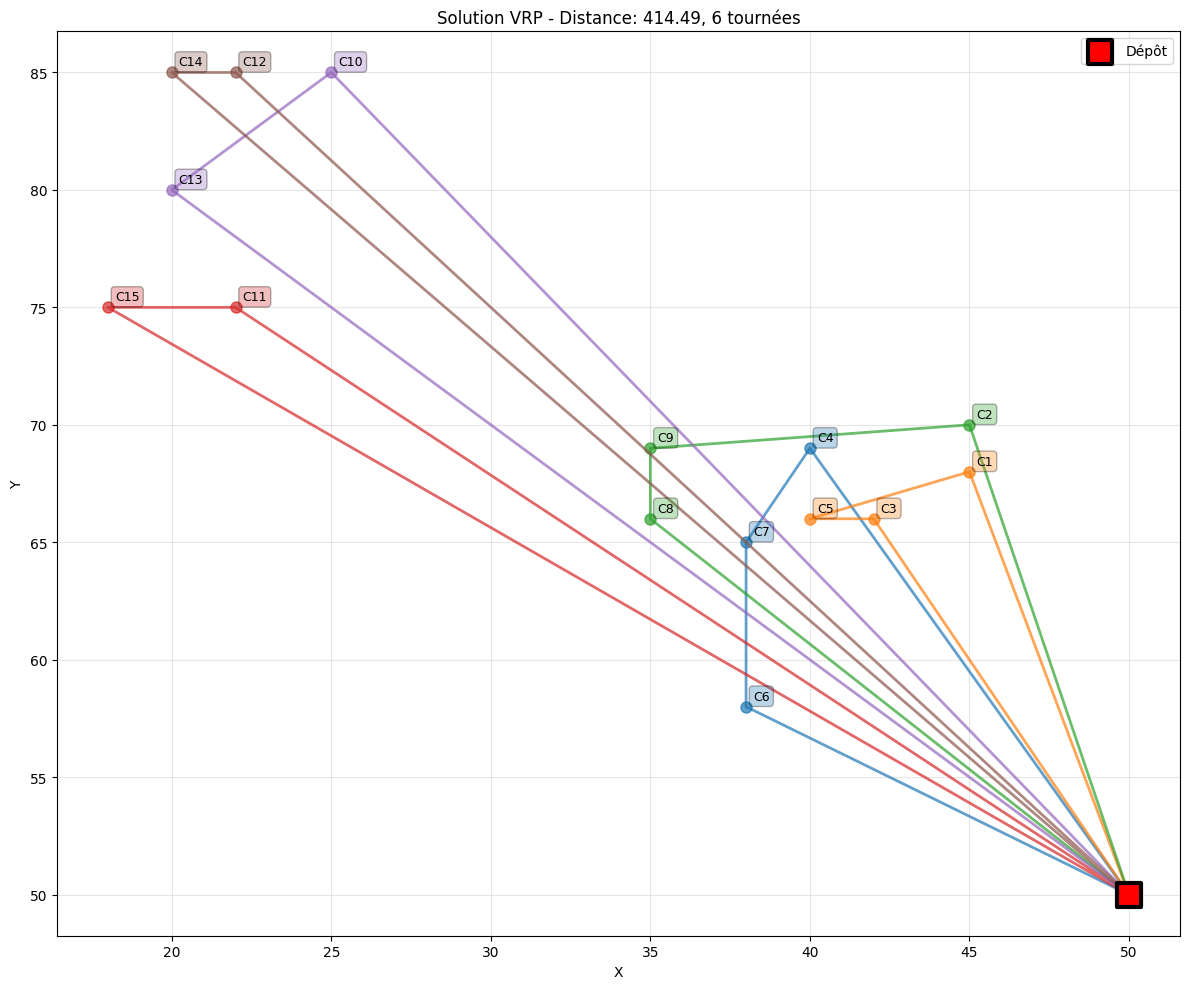

In [9]:
# Appliquer 2-opt
improved_solution = two_opt_vrp(solution)
print(f"Avant 2-opt: {solution.total_distance():.2f}")
print(f"Après 2-opt: {improved_solution.total_distance():.2f}")
print(f"Amélioration: {solution.total_distance() - improved_solution.total_distance():.2f}")

plot_solution(improved_solution)

### Interpretation : Amélioration 2-opt

**Sortie obtenue** : Comparaison des distances avant et après l'application de l'algorithme 2-opt, avec visualisation des tournées optimisées.

| Aspect | Valeur | Signification |
|--------|--------|---------------|
| Distance avant 2-opt | ~417.49 | Solution initiale gloutonne |
| Distance après 2-opt | ~414.49 | Solution améliorée par recherche locale |
| Amélioration | 3.00 (≈ 0,72 %) | Réduction de la distance totale (417,49 → 414,49) |
| Tournées optimisées | 6 | Structure des routes préservée |

**Points clés** :
1. **2-opt** : Métaheuristique de recherche locale qui inverse des segments de tournées pour réduire les croisements
2. **Préservation des contraintes** : Les capacités des véhicules restent respectées après optimisation
3. **Amélioration incrémentale** : L'algorithme explore le voisinage de la solution courante pour trouver des améliorations locales
4. **Optima locaux** : 2-opt peut rester bloqué dans un optimum local (d'où l'intérêt de métaheuristiques comme le recuit simulé)

> **Note technique** : 2-opt est particulièrement efficace pour éliminer les croisements dans les tournées. Pour le VRP, on l'applique indépendamment à chaque tournée. La complexité est de O(n²) par tournée, ce qui reste raisonnable pour des instances de taille moyenne.


## 7. Exercices

### Exercice 1 : Algorithme du Plus Proche Voisin

Implémentez un algorithme qui construit les tournées en sélectionnant toujours le client le plus proche du dernier client visité, tout en respectant les contraintes de capacité.

In [10]:
# TODO: Implémenter nearest_neighbor()
# def nearest_neighbor(instance: VRPInstance) -> VRPSolution:
#     """Construit des tournées avec l'algorithme du plus proche voisin."""
#     pass

### Exercice 2 : Métaheuristique - Recuit Simulé

Implémentez un algorithme de recuit simulé pour explorer l'espace de solutions et échapper aux optima locaux.

In [11]:
# TODO: Implémenter simulated_annealing()
# def simulated_annealing(initial_solution: VRPSolution, 
#                         initial_temp: float = 1000,
#                         cooling_rate: float = 0.995) -> VRPSolution:
#     """Améliore une solution avec le recuit simulé."""
#     pass

### Exercice 3 : VRP avec Fenêtres de Temps (VRPTW)

Étendez le modèle pour inclure des contraintes de fenêtres de temps pour chaque client (temps minimum et maximum de livraison).

In [12]:
# TODO: Implémenter VRPTWInstance et validate_time_windows()
# @dataclass
# class VRPTWInstance(VRPInstance):
#     time_windows: List[Tuple[int, int]]  # (earliest, latest)
#     service_times: List[int]  # Temps de service par client
#     pass

## 8. Résumé

Dans ce notebook, nous avons exploré :

1. **Modélisation VRP** : Représentation formelle du problème
2. **Algorithme glouton** : Construction de solution par insertion
3. **Recherche locale** : Amélioration avec 2-opt
4. **Visualisation** : Tracé des tournées et des clients

### Perspectives

- **Métaheuristiques avancées** : Algorithmes génétiques, colonie de fourmis
- **Problèmes dynamiques** : VRP avec demandes dynamiques
- **Applications réelles** : Logistique, transport de marchandises, livraison

### Références

- Toth, P., & Vigo, D. (2014). *The Vehicle Routing Problem*
- Cordeau, J. F., et al. (2002). *A guide to vehicle routing heuristics*
- Russell, S., & Norvig, P. (2020). *Artificial Intelligence: A Modern Approach* - Chapitre 10